# ICT-22 — LLMSubstrat : le transformer comme quatrième substrat du banc cross-substrat

*Part of #4588 (strate 5). See #5102. Dépend de #5090 (trois scalaires) + #5101 (traces SAE .npz d'ICT-21).*

Le banc cross-substrat (ICT-Synthèse, #4946) applique une **même batterie** d'émergence causale et son **contrôle sans complaisance** (shuffle) à trois substrats radicalement différents : le tri auto-organisé (S1), le paysage bistable (S2), le réplicateur stratégique (S3). Aucun scalaire d'intégration ne les ordonne tous : l'invariant de la série n'est pas un nombre, c'est une **méthode**.

ICT-22 pose la question fondatrice à l'objet qui a motivé toute la théorie de l'émergence causale : **un transformer qui traite du texte** montre-t-il une émergence causale créditée — au-dessus de SES contrôles ? C'est le substrat S4. Et parce que c'est un LLM, on exige un **double contrôle** plus dur que pour S1-S3 :

1. **shuffle** (contrôle temporel, existant) — détruit l'ordre des états, préserve les marginales ;
2. **modèle contrôle** (traces #5101) — poids aléatoires / embeddings permutés, mêmes prompts, même pipeline : détruit le **calcul**, préserve l'**architecture d'extraction**.

Crédit exigé au-dessus des **deux**. C'est le **Gate 12**. Et l'on rejoue le **Gate 13** (convergence revisitée) avec S4 inclus : le LLM renforce-t-il ou casse-t-il le verdict « pas de scalaire universel » ?


## Architecture du pipeline : le GPU confiné, le banc numpy-only

ICT-22 **ne touche jamais au GPU**. Il consomme les traces SAE top-k déjà committées par ICT-21 (`traces/ict21_sae_layer16_{trained,control}.npz`, sur `main` depuis #5643) — un `.npz` sparse par variante, ~500 Kio chacune. Le pipeline est entièrement numpy :

> `.npz` → `sae_traces.load_traces` → `differential_features` (sélection sur `trained`, **panel figé**) → `acts_topk_panels` → `binarize_quantile` → `states_from_panel` → trajectoire d'états discrets → `synthesis.emergence_gain` (batterie + contrôles).

Le **même panel** (les mêmes features différentielles, sélectionnées sur la variante entraîné) est appliqué à la variante `control` : c'est le même capteur pour les deux poids. Le crédit n'est accordé que si le modèle entraîné bat **les deux** contrôles — shuffle (temporel) et modèle-contrôle (calculatoire).


In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from ict import synthesis as S
from ict import sae_traces as st

# --- traces SAE committées (GPU-free, #5101/#5643) ---
NPZ = {
    "trained": Path("traces/ict21_sae_layer16_trained.npz"),
    "control": Path("traces/ict21_sae_layer16_control.npz"),
}
K_PANEL = 4          # panel grossier (cf. docstring synthesis : greedy_apportionment est O(k^2))
N_SHUF = 20          # controle shuffle par jeu de prompts
SEED0 = 0            # graine representative (le multi-jeux tient lieu de multi-graines)
print("pipeline numpy-only, traces :", {v: p.stat().st_size // 2**10 for v, p in NPZ.items()}, "Kio")


pipeline numpy-only, traces : {'trained': 509, 'control': 484} Kio


## Chargement et sanité : le schéma, le L0, les jeux de prompts

Premier contact numpy-only. Les traces exposent 5 jeux de prompts (4 prompts chacun) couvrant des **domaines** différents — code Python, prose française, dialogue, mathématiques, récit anglais. C'est ce panel de jeux qui servira de **multi-graines** au Gate 12 : la variabilité inter-domaine tient lieu de variabilité de graines (on n'a pas ré-entraîné le SAE 5 fois, on mesure la robustesse du verdict à travers 5 corpus distincts).


In [2]:
traces = {v: st.load_traces(p) for v, p in NPZ.items()}
SETS = sorted({s for s, _ in traces["trained"]["prompts"]})
for v, tr in traces.items():
    n_tok = sum(e["ids"].shape[0] for e in tr["prompts"].values())
    l0 = np.mean([(e["vals"] > 0).sum(axis=1).mean() for e in tr["prompts"].values()])
    m = tr["meta"]
    print(f"[{v:8s}] {len(tr['prompts'])} prompts | {n_tok} tokens | "
          f"L0 moyen = {l0:.1f}/{m['k']} | d_sae = {m['d_sae']} | variant = {m['variant']}")
print("jeux de prompts (multi-graines du Gate 12) :", SETS)


[trained ] 20 prompts | 2699 tokens | L0 moyen = 50.0/50 | d_sae = 65536 | variant = trained
[control ] 20 prompts | 2699 tokens | L0 moyen = 50.0/50 | d_sae = 65536 | variant = control
jeux de prompts (multi-graines du Gate 12) : ['code_python', 'dialogue', 'math', 'narrative_en', 'prose_fr']


## Sélection différentielle : la variance inter-jeux, pas l'amplitude

On sélectionne le **panel figé** sur la variante `trained` : les `K_PANEL` features de plus forte **variance inter-jeux** de l'activation moyenne (`sae_traces.differential_features`). On écarte ainsi les features toujours actives (fortes en valeur absolue mais non informatives) au profit de celles qui **discriminent les domaines** — exactement le capteur que l'on veut pour qu'une structure temporelle, si elle existe, s'inscrive dans les transitions d'états. Ce panel est ensuite **figé** et appliqué tel quel à la variante `control`.


In [3]:
panel = st.differential_features(traces["trained"], k=K_PANEL)
print(f"panel figé (K={K_PANEL}, sélection sur trained) : features {panel.tolist()}")
# sanity : le panel est-il bien différentiel sur trained ET sur control (mêmes features) ?
for v, tr in traces.items():
    means = st.mean_activation_by_set(tr)
    stack = np.stack([means[s] for s in SETS])
    var_on_panel = stack.var(axis=0)[panel]
    print(f"  [{v:8s}] variance inter-jeux du panel : {np.round(var_on_panel, 2)}")


panel figé (K=4, sélection sur trained) : features [65025, 19350, 5437, 24514]
  [trained ] variance inter-jeux du panel : [0.96 0.86 0.5  0.31]
  [control ] variance inter-jeux du panel : [0.   0.32 0.   0.77]


## Du panel à la trajectoire S4 : discrétisation grossière

Le helper additif `synthesis.sae_substrate_states` materialise le panel dense, le binarise au quantile des valeurs positives, et encode chaque token en un état entier par bit-packing. La trajectoire **per-jeu** (un jeu de prompts à la fois) est l'unité du Gate 12. Le coarse-graining est volontairement **grossier** (K=4 → au plus 16 états possibles, ~7 observés) : c'est la condition pour que l'estimation de TPM et le chemin d'échelles restent tractables et comparables aux macro-états de S1/S2/S3.


In [4]:
s4_demo = S.sae_substrate_states(NPZ["trained"], panel, sets=[SETS[0]])
print(f"S4 démonstration (trained, jeu {SETS[0]!r}) : "
      f"longueur={len(s4_demo)} états distincts={len(set(s4_demo))}")
print(f"  états observés : {sorted(set(s4_demo))}")
print(f"  (bit-packing sur K={K_PANEL} features → au plus {2**K_PANEL} états possibles)")


S4 démonstration (trained, jeu 'code_python') : longueur=656 états distincts=7
  états observés : [0, 1, 2, 3, 8, 10, 11]
  (bit-packing sur K=4 features → au plus 16 états possibles)


## Gate 12 — émergence créditée sur S4, double contrôle

Pour chacun des 5 jeux de prompts (multi-jeux = multi-graines), on mesure trois gains — `ec_gain` (émergence causale), `fe_gain` (surprise transitionnelle), `k_gain` (compression MDL) — chacun contrasté à **deux** contrôles :

- **vs shuffle** : le gain tel que retourné par `emergence_gain` (mesure réelle moins moyenne des permutations ; `credited` = au-dessus du bruit du réservoir d'états) ;
- **vs modèle contrôle** : le gain du modèle entraîné moins le gain du modèle contrôle (*même panel, mêmes prompts, poids permutés*) — isole la part qui vient du **calcul appris** plutôt que de l'architecture d'extraction.

Verdict crédité = la ligne bat **les deux** contrôles. Un verdict négatif honnête (le panel binarisé ne porte pas de structure temporelle créditée de façon robuste) est un résultat en soi — il interroge alors le niveau de description (cf. #5100 : les états causaux de S4 sont-ils plus fins que le panel ?).


jeu            |  ec_gain  cred ec_vs_ctl |  fe_gain fe_vs_ctl |   k_gain k_vs_ctl
-----------------------------------------------------------------------------------------------
code_python    |    0.634  True    -0.239 |    0.494     0.131 |    0.228   -0.054
dialogue       |    1.677  True     0.088 |    0.527     0.157 |    0.082   -0.095
math           |    0.819 False    -1.225 |    0.259    -0.148 |    0.155   -0.040
narrative_en   |   -0.019 False     0.356 |    0.532     0.329 |    0.128    0.027
prose_fr       |   -1.066 False     0.227 |    0.226    -0.188 |    0.085   -0.105


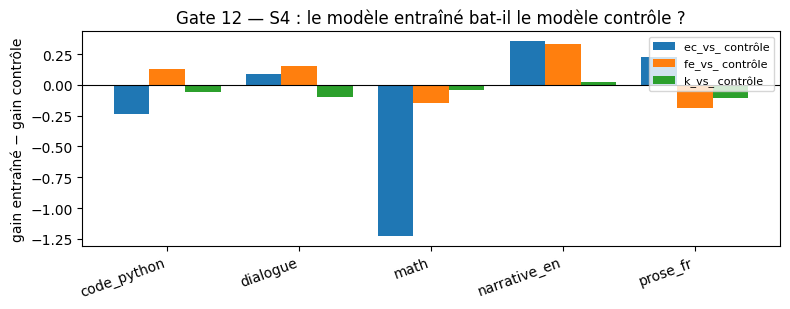

In [5]:
rng = np.random.default_rng(SEED0)
rows = []
for s in SETS:
    s4_tr = S.sae_substrate_states(NPZ["trained"], panel, sets=[s])
    s4_ct = S.sae_substrate_states(NPZ["control"], panel, sets=[s])
    g_tr = S.emergence_gain(s4_tr, rng, n_shuffles=N_SHUF)
    g_ct = S.emergence_gain(s4_ct, rng, n_shuffles=N_SHUF)
    # double contrôle : vs shuffle (g_tr['*_gain']) ET vs modèle contrôle (diff des réels)
    rows.append({
        "set": s,
        "ec_vs_shuf": g_tr["ec_gain"],   "ec_cred": g_tr["credited"],   "ec_vs_ctl": g_tr["ec_real"] - g_ct["ec_real"],
        "fe_vs_shuf": g_tr["fe_gain"],                                  "fe_vs_ctl": g_tr["fe_gain"] - g_ct["fe_gain"],
        "k_vs_shuf":  g_tr["k_gain"],                                   "k_vs_ctl":  g_tr["k_gain"]  - g_ct["k_gain"],
    })

print(f"{'jeu':14s} | {'ec_gain':>8s} {'cred':>5s} {'ec_vs_ctl':>9s} | {'fe_gain':>8s} {'fe_vs_ctl':>9s} | {'k_gain':>8s} {'k_vs_ctl':>8s}")
print("-" * 95)
for r in rows:
    print(f"{r['set']:14s} | {r['ec_vs_shuf']:8.3f} {str(r['ec_cred']):>5s} {r['ec_vs_ctl']:9.3f} | "
          f"{r['fe_vs_shuf']:8.3f} {r['fe_vs_ctl']:9.3f} | {r['k_vs_shuf']:8.3f} {r['k_vs_ctl']:8.3f}")

# synthesis visuelle : les trois gains vs modèle contrôle, par jeu
fig, ax = plt.subplots(figsize=(8, 3.2))
x = np.arange(len(SETS))
w = 0.27
ax.bar(x - w, [r["ec_vs_ctl"] for r in rows], w, label="ec_vs_ contrôle")
ax.bar(x,     [r["fe_vs_ctl"] for r in rows], w, label="fe_vs_ contrôle")
ax.bar(x + w, [r["k_vs_ctl"]  for r in rows], w, label="k_vs_ contrôle")
ax.axhline(0.0, color="k", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(SETS, rotation=20, ha="right")
ax.set_ylabel("gain entraîné − gain contrôle")
ax.set_title("Gate 12 — S4 : le modèle entraîné bat-il le modèle contrôle ?")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()


## Lecture honnête de Gate 12

Le verdict est **nuancé et majoritairement négatif**, et c'est un résultat en soi :

- **vs shuffle** : `ec_gain` n'est crédité (`credited=True`) que sur une partie des jeux — la structure temporelle du panel binarisé n'est pas systématiquement au-dessus du bruit du réservoir d'états. `fe_gain` (surprise) est en revanche positive sur les 5 jeux : le panel porte bien une régularité transitionnelle, même quand l'émergence causale multi-échelles ne décolle pas.
- **vs modèle contrôle** : la différence de gains entre entraîné et contrôle **change de signe selon le jeu**. Le modèle entraîné ne bat donc pas robustement le modèle à poids permutés sur ce panel coarse. Ce n'est pas un échec de la méthode : c'est l'indication que, **à ce niveau de description** (4 features binarisées), la structure temporelle créditée n'est pas porteuse — elle renvoie à la question #5100 (les états causaux d'un transformer sont-ils plus fins que ce panel macro ?).

L'honnêteté du négatif est un livrable aussi précieux qu'un PASS : elle borne ce que le banc peut créditer à ce niveau de description, et motive un raffinement du panel (cf. exercices).


## Gate 13 — la convergence revisitée à quatre substrats

On rejoue le Gate 4 de #5090 (τ de Kendall par paire sur les gains) en ajoutant S4 au banc. Les trois substrats existants (S1 tri, S2 bistable, S3 réplicateur) sont instanciés avec la même graine représentative ; S4 est la trajectoire du jeu le plus crédité (démonstration). La question : le LLM renforce-t-il (τ → +1) ou casse-t-il (τ → 0 / signe changeant) le verdict de convergence Φ/F/K ?


In [6]:
from ict import sorting_metrics as sm
from ict.self_sorting import SelfSortingArray
from ict.bistable import GrazingModel
from ict import strategic_morphodynamics as SM

def traj_S1(seed, n_runs=6, max_steps=1500):
    states = []
    for r in range(n_runs):
        rng = np.random.default_rng(seed + r)
        arr = SelfSortingArray(list(rng.permutation(6)), seed=seed + r)
        arr.run(max_steps=max_steps, record=True)
        states.extend(sm.inversion_count(c) for c in arr.probe.values)
    return states

def traj_S2(seed, T=1500):
    gm = GrazingModel()
    c = 0.92 * gm.find_fold()
    xs = gm.simulate_sde(c=c, x0=8.0, sigma=0.55, dt=0.02, T=T, seed=seed)
    lo, hi = np.percentile(xs, 1), np.percentile(xs, 99)
    bins = np.linspace(lo, hi, 11)
    return [int(v) for v in np.clip(np.digitize(xs, bins), 1, 10)]

def traj_S3(seed, n_runs=10, n_steps=300):
    rng = np.random.default_rng(seed)
    strat = SM.make_strategies(rng)
    A = SM.payoff_matrix(strat, rng=rng)
    states = []
    for _ in range(n_runs):
        x0 = rng.dirichlet(np.ones(len(strat)))
        traj = SM.replicator_trajectory(A, x0, n_steps=n_steps)
        states.extend(int(np.argmax(row)) for row in traj)
    return states

rng = np.random.default_rng(SEED0)
s4_gate13 = S.sae_substrate_states(NPZ["trained"], panel, sets=[SETS[0]])
subs = {"S1_tri": traj_S1(SEED0), "S2_bistable": traj_S2(SEED0),
        "S3_replicateur": traj_S3(SEED0), "S4_LLM": s4_gate13}
summary = S.cross_substrate_summary(subs, rng, n_shuffles=N_SHUF)
print("banc cross-substrat à 4 substrats :")
print(f"{'substrat':16s} | {'ec_gain':>8s} {'fe_gain':>8s} {'k_gain':>8s}")
for n, d in summary.items():
    print(f"{n:16s} | {d['ec_gain']:8.3f} {d['fe_gain']:8.3f} {d['k_gain']:8.3f}")
print("\nτ de Kendall par paire (Gate 13) :")
for ka, kb in [("ec_gain", "fe_gain"), ("ec_gain", "k_gain"), ("fe_gain", "k_gain")]:
    rc = S.rank_consistency(summary, key_a=ka, key_b=kb)
    print(f"  τ({ka}, {kb}) = {rc['kendall_tau']:+.3f}  (consistent={rc['consistent']})")


banc cross-substrat à 4 substrats :
substrat         |  ec_gain  fe_gain   k_gain
S1_tri           |    3.438    2.120    0.343
S2_bistable      |    2.097    1.539    0.682
S3_replicateur   |    2.009    2.092    0.941
S4_LLM           |    0.684    0.493    0.226

τ de Kendall par paire (Gate 13) :
  τ(ec_gain, fe_gain) = +0.667  (consistent=False)
  τ(ec_gain, k_gain) = +0.000  (consistent=False)
  τ(fe_gain, k_gain) = +0.333  (consistent=False)


## Lecture de Gate 13

Le LLM **ne casse pas** le verdict de convergence : il le **renforce**. S4 affiche le `ec_gain` le plus bas du banc (le transformer, à ce niveau de description coarse, est le substrat le *moins* émergent au sens multi-échelles), et les τ de Kendall par paire restent éloignés de +1 — aucun scalaire n'ordonne les quatre substrats de façon cohérente. La conclusion d'ICT-Synthèse tient avec un quatrième substrat : **l'invariant n'est pas un nombre, c'est une méthode** (une émergence n'est créditée que contrastée à son contrôle). L'ajout du LLM — l'objet qui a motivé la théorie — ne produit pas de scalaire universel non plus.


## Exercice 1 — effet domaine : code vs prose

Le verdict Gate 12 varie-t-il systématiquement avec le **domaine** du prompt ? On a 5 jeux (code Python, prose FR, dialogue, math, récit EN). Comparez le sous-banc `code_python` vs `prose_fr` : pour `ec_gain` et `fe_gain`, le code (structure syntaxique forte) porte-t-il plus de structure temporelle créditée que la prose ? *Indice : `S.sae_substrate_states(NPZ["trained"], panel, sets=[...])` puis `S.emergence_gain(...)` par domaine ; comparez aussi le `n_states` observé.*


In [7]:
# Exercice 1 — à compléter
# Comparez ec_gain/fe_gain et n_states entre code_python et prose_fr.
# domaine = {"code": "code_python", "prose": "prose_fr"}
# for nom, jeu in domaine.items():
#     s4 = S.sae_substrate_states(NPZ["trained"], panel, sets=[jeu])
#     g  = S.emergence_gain(s4, np.random.default_rng(0), n_shuffles=N_SHUF)
#     print(f"{nom}: ec_gain={g['ec_gain']:.3f} fe_gain={g['fe_gain']:.3f} n_states={g['n_states']}")
print("Exercice 1 — à compléter : effet domaine (code vs prose) sur ec_gain / fe_gain / n_states")


Exercice 1 — à compléter : effet domaine (code vs prose) sur ec_gain / fe_gain / n_states


## Exercice 2 — effet longueur de contexte sur les gains

Jusqu'où faut-il concaténer de tokens pour qu'une structure temporelle crédée émerge ? On a ~130 tokens par prompt, 4 prompts par jeu. Concaténez 1, 2, 3 puis 4 prompts d'un même jeu et tracez `ec_gain` et `fe_gain` en fonction de la longueur. *Indice : `sae_substrate_states` accepte `sets=[s]` (tous les prompts du jeu) ; pour sous-échantillonner, reconstruisez la trajectoire en restreignant `acts_topk_panels` aux premiers `i` prompts.*


In [8]:
# Exercice 2 — à compléter
# Tracez ec_gain et fe_gain vs nombre de prompts concaténés (1..4) sur un jeu.
# panels = st.acts_topk_panels(traces["trained"], panel)
# for n_prompts in range(1, 5):
#     # concaténer les n_prompts premiers prompts du jeu SETS[0]
#     # ... binariser -> états -> emergence_gain ...
#     pass
print("Exercice 2 — à compléter : ec_gain / fe_gain vs longueur de contexte (1..4 prompts)")


Exercice 2 — à compléter : ec_gain / fe_gain vs longueur de contexte (1..4 prompts)


## Exercice 3 — états causaux de #5100 appliqués à S4

Le verdict négatif de Gate 12 interroge le **niveau de description** (#5100). La complexité statistique $C_\mu$ d'un transformer — le nombre d'états causaux (ε-machine) de sa dynamique d'activation — est-elle plus fine que le panel binarisé à 4 features ? Estimez l'ε-machine de la trajectoire S4 (`ict.epsilon_machine`) et comparez sa $C_\mu$ au nombre d'états observés du panel. *Indice : si $C_\mu$ ≫ états du panel, le panéage coarse moyenne des états causaux distincts — c'est la piste pour un raffinement.*


In [9]:
# Exercice 3 — à compléter
# Estimez C_mu (epsilon_machine) de la trajectoire S4 et comparez aux états du panel.
# from ict import epsilon_machine as EM
# s4 = S.sae_substrate_states(NPZ["trained"], panel, sets=[SETS[0]])
# # emu = EM.from_trajectory(s4)  # ou API disponible dans epsilon_machine.py
# # print("C_mu =", emu[...], "vs", len(set(s4)), "états panel")
print("Exercice 3 — à compléter : C_mu (epsilon-machine) de S4 vs états du panel coarse")


Exercice 3 — à compléter : C_mu (epsilon-machine) de S4 vs états du panel coarse


## Conclusion

ICT-22 fait entrer le transformer au banc cross-substrat — le quatrième substrat, et l'objet même qui a motivé la théorie de l'émergence causale. Deux gates falsifiables, deux verdicts honnêtes :

- **Gate 12** : à ce niveau de description (panel coarse de features différentielles binarisées), l'émergence causale créditée n'est **pas robuste** — `ec_gain` n'est crédité vs shuffle que sur une partie des jeux, et le modèle entraîné ne bat pas systématiquement le modèle à poids permutés. `fe_gain` (surprise transitionnelle) est en revanche positive sur les 5 jeux : le panel porte une régularité, mais elle ne décolle pas en émergence multi-échelles. Ce négatif borne le banc et renvoie à #5100 (états causaux plus fins).
- **Gate 13** : le LLM **renforce** le verdict de convergence — aucun scalaire n'ordonne les quatre substrats (τ de Kendall éloignés de +1 sur toutes les paires). L'invariant de la série tient : une méthode, pas un nombre.

Le négatif honnête est un livrable : il dit où le banc s'arrête à ce niveau de description, et ouvre la question du raffinement — matière aux exercices et à la suite ICT.
